In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import spacy
from nltk.corpus import stopwords
from bertopic import BERTopic
from sklearn.linear_model              import LogisticRegression
from sklearn.model_selection           import cross_val_score, train_test_split
from sklearn.metrics                   import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text   import CountVectorizer
from hdbscan import HDBSCAN

/opt/anaconda3/envs/text-analytics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data preparation

In [12]:
df = pd.read_csv('data/reddit_posts_further_reduced.csv')

In [13]:
df

,Title,Political Lean,Score,Subreddit,Num of Comments,Text,Date Created
0,"No matter who someone is, how they look like, ...",Liberal,1,socialism,0,NaN,1.646272e+09
1,Biden speech draws 38.2 million U.S. TV viewers,Liberal,6,democrats,1,NaN,1.646271e+09
2,State of the union,Liberal,1,DemocraticSocialism,1,Who watched the state of the union last night ...,1.646270e+09
3,Do it for the Dew,Liberal,6,democrats,1,NaN,1.646268e+09
4,Proposed Bill Would Allow Kids With Contagious...,Liberal,3,progressive,5,NaN,1.646268e+09
...,...,...,...,...,...,...,...
9994,Libertarian Revolution? Not Exactly,Conservative,2,anarchocapitalism,0,NaN,1.293653e+09
9995,Libertarianism and Anarchy,Conservative,3,anarchocapitalism,1,NaN,1.293222e+09
9996,Problems of Transhumanism,Conservative,2,anarchocapitalism,0,NaN,1.293164e+09
9997,Ron Paul’s Spirited Defense of WikiLeaks & Fre...,Conservative,2,anarchocapitalism,1,NaN,1.292421e+09


In [14]:
'''
# reduce the size of the dataset in accordance with the ethics committee feedback
drop_idx = df.sample(frac=0.15, random_state=42).index
df_reduced = df.drop(index=drop_idx).reset_index(drop=True)
df_reduced = df_reduced[df_reduced['Subreddit']!='RadicalFeminism'] # drop the RadicalFeminism as it contains less than 100 posts
# df_reduced.to_csv('data/reddit_posts_reduced.csv', index=False) # save as csv
'''

"\n# reduce the size of the dataset in accordance with the ethics committee feedback\ndrop_idx = df.sample(frac=0.15, random_state=42).index\ndf_reduced = df.drop(index=drop_idx).reset_index(drop=True)\ndf_reduced = df_reduced[df_reduced['Subreddit']!='RadicalFeminism'] # drop the RadicalFeminism as it contains less than 100 posts\n# df_reduced.to_csv('data/reddit_posts_reduced.csv', index=False) # save as csv\n"

In [15]:
df['Political Lean'].value_counts()

Political Lean
Liberal         6426
Conservative    3573
Name: count, dtype: int64

In [16]:
df

,Title,Political Lean,Score,Subreddit,Num of Comments,Text,Date Created
0,"No matter who someone is, how they look like, ...",Liberal,1,socialism,0,NaN,1.646272e+09
1,Biden speech draws 38.2 million U.S. TV viewers,Liberal,6,democrats,1,NaN,1.646271e+09
2,State of the union,Liberal,1,DemocraticSocialism,1,Who watched the state of the union last night ...,1.646270e+09
3,Do it for the Dew,Liberal,6,democrats,1,NaN,1.646268e+09
4,Proposed Bill Would Allow Kids With Contagious...,Liberal,3,progressive,5,NaN,1.646268e+09
...,...,...,...,...,...,...,...
9994,Libertarian Revolution? Not Exactly,Conservative,2,anarchocapitalism,0,NaN,1.293653e+09
9995,Libertarianism and Anarchy,Conservative,3,anarchocapitalism,1,NaN,1.293222e+09
9996,Problems of Transhumanism,Conservative,2,anarchocapitalism,0,NaN,1.293164e+09
9997,Ron Paul’s Spirited Defense of WikiLeaks & Fre...,Conservative,2,anarchocapitalism,1,NaN,1.292421e+09


In [17]:
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')

In [18]:
df = df.rename(columns={"Title": "title", "Text": "selftext"})

In [9]:
def minimal_clean(text: str) -> str:
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"https?://\S+", "", text)
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# clean the df
df["title_clean"]    = df["title"].apply(minimal_clean)
df["selftext_clean"] = df["selftext"].apply(minimal_clean)

# combine into docs for bertopic
docs = (df["title_clean"] + " " + df["selftext_clean"].fillna("")).tolist()

In [19]:
# posts containing at least one URL in title + selftext
combined = df['title'].fillna('') + ' ' + df['selftext'].fillna('')
url_pattern = r'https?://\S+'
has_url = combined.str.contains(url_pattern)
print(f"{has_url.sum()} posts contain URLs out of {len(df)} total")

# remove URLs from title and selftext
df['title']    = df['title'].str.replace(url_pattern, '', regex=True)
df['selftext'] = df['selftext'].str.replace(url_pattern, '', regex=True)

503 posts contain URLs out of 9999 total


In [20]:
# stop words list
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_str(text):
    if pd.isna(text):
        return ""
    # lowercase
    text = text.lower()
    # remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # split, filter out short tokens & stop-words, then re-join
    tokens = text.split()
    tokens = [w for w in tokens if len(w) >= 3 and w not in stop_words]
    return " ".join(tokens)

# Apply to title and body, storing cleaned strings
df['title']  = df['title'].apply(clean_str)
df['selftext']   = df['selftext'].apply(clean_str)

In [87]:
'''
# if we want to lemmatize
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser","ner","textcat"]  # only need tokenizer, tagger, lemmatizer
)

def clean_str(text: str) -> str:
    if pd.isna(text):
        return ""
    # lowercase & strip non-letters
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)

    # b) apply spaCy pipeline
    doc = nlp(text)

    # c) filter & lemmatize
    lemmas = [
        token.lemma_
        for token in doc
        if token.is_alpha             # skip punctuation/numbers
           and not token.is_stop         # skip spaCy’s built-in stop words
           and len(token.lemma_) >= 3    # skip very short lemmas
    ]

    # d) re-join into a cleaned string
    return " ".join(lemmas)

# Apply to your DataFrame in exactly the same way:
df["title"]    = df["title"].apply(clean_str)
df["selftext"] = df["selftext"].apply(clean_str)
'''

'\n# if we want to lemmatize\nnlp = spacy.load(\n    "en_core_web_sm",\n    disable=["parser","ner","textcat"]  # only need tokenizer, tagger, lemmatizer\n)\n\ndef clean_str(text: str) -> str:\n    if pd.isna(text):\n        return ""\n    # lowercase & strip non-letters\n    text = text.lower()\n    text = re.sub(r"[^a-z\\s]", " ", text)\n\n    # b) apply spaCy pipeline\n    doc = nlp(text)\n\n    # c) filter & lemmatize\n    lemmas = [\n        token.lemma_\n        for token in doc\n        if token.is_alpha             # skip punctuation/numbers\n           and not token.is_stop         # skip spaCy’s built-in stop words\n           and len(token.lemma_) >= 3    # skip very short lemmas\n    ]\n\n    # d) re-join into a cleaned string\n    return " ".join(lemmas)\n\n# Apply to your DataFrame in exactly the same way:\ndf["title"]    = df["title"].apply(clean_str)\ndf["selftext"] = df["selftext"].apply(clean_str)\n'

In [88]:
df

,title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,selftext,Date Created
0,matter someone look like language speak wear r...,Liberal,1,t5fybt,socialism,https://v.redd.it/ng5fyl7hp2l81,0,,2022-03-03 01:42:57
1,biden speech draws million viewers,Liberal,6,t5fqdn,democrats,https://www.reuters.com/world/us/biden-speech-...,1,,2022-03-03 01:31:48
2,state union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,watched state union last night opinion,2022-03-03 01:21:28
3,give poor people money,Liberal,7,t5f7n9,SocialDemocracy,https://youtu.be/a80kRjpubG0,3,,2022-03-03 01:05:08
4,dew,Liberal,6,t5es2c,democrats,https://i.redd.it/drmunn90f2l81.jpg,1,,2022-03-03 00:43:03
...,...,...,...,...,...,...,...,...,...
10921,problems transhumanism,Conservative,2,eqrs0,anarchocapitalism,http://ieet.org/index.php/IEET/more/hughes2010...,0,,2010-12-24 04:20:16
10922,ron paul spirited defense wikileaks free infor...,Conservative,2,em7rm,anarchocapitalism,http://www.deathandtaxesmag.com/40485/ron-paul...,1,,2010-12-15 13:54:29
10923,anarcho capitalism opinion doctrinal system ev...,Conservative,2,ei98o,anarchocapitalism,http://www.pressaction.com/news/weblog/full_ar...,1,,2010-12-08 12:53:14
10924,mises wiki wiki project dedicated advancement ...,Conservative,2,e6x22,anarchocapitalism,http://wiki.mises.org/wiki/Main_Page,0,,2010-11-16 12:17:27


In [112]:
df['Political Lean'].value_counts()

Political Lean
Liberal         6978
Conservative    3861
Name: count, dtype: int64

In [113]:
df.columns

Index(['title', 'Political Lean', 'Score', 'Id', 'Subreddit', 'URL',
       'Num of Comments', 'selftext', 'Date Created', 'title_clean',
       'selftext_clean'],
      dtype='object')

## Topic Modeling

In [21]:
# Ensure selftext has no NaNs
df["selftext"] = df["selftext"].fillna("")

# Build docs by combining title + selftext (only if selftext isn’t empty)
docs = (
    df.apply(
        lambda row: row["title"] + " " + row["selftext"]
        if row["selftext"].strip() != ""
        else row["title"],
        axis=1,
    )
    .tolist()
)

y = df["Political Lean"].map({"Liberal": 0, "Conservative": 1})

In [10]:
y = df["Political Lean"].map({"Liberal": 0, "Conservative": 1})

2025-06-04 12:16:25,249 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 313/313 [00:14<00:00, 21.97it/s]
2025-06-04 12:16:41,267 - BERTopic - Embedding - Completed ✓
2025-06-04 12:16:41,267 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-04 12:16:44,110 - BERTopic - Dimensionality - Completed ✓
2025-06-04 12:16:44,111 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-04 12:16:49,249 - BERTopic - Cluster - Completed ✓
2025-06-04 12:16:49,255 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-06-04 12:16:49,433 - BERTopic - Representation - Completed ✓


5-fold CV AUC: 0.695 ± 0.026
5-fold CV Balanced Accuracy: 0.618 ± 0.047
              precision    recall  f1-score   support

     Liberal       0.74      0.86      0.80      1285
Conservative       0.65      0.47      0.54       715

    accuracy                           0.72      2000
   macro avg       0.69      0.66      0.67      2000
weighted avg       0.71      0.72      0.71      2000



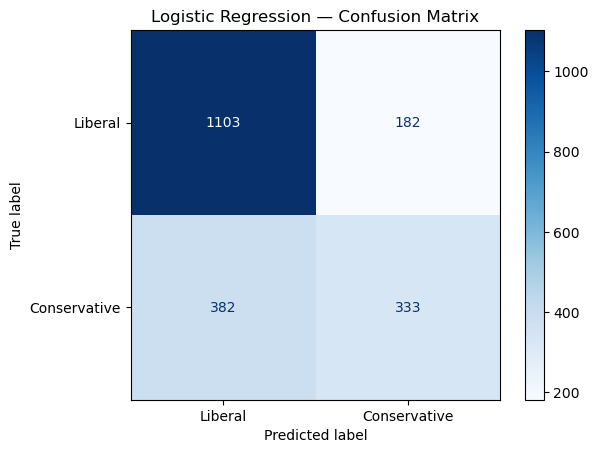

In [22]:
# Fit BERTopic with full probability matrix
topic_model = BERTopic(calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)

# Evaluate with 5-fold CV AUC
X = np.array(probs)                     # shape: (n_docs, n_topics)
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
auc_scores = cross_val_score(clf, X, y, cv=5, scoring="roc_auc")
print(f"5-fold CV AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
bal_scores = cross_val_score(clf, X, y, cv=5, scoring="balanced_accuracy")
print(f"5-fold CV Balanced Accuracy: {bal_scores.mean():.3f} ± {bal_scores.std():.3f}")# better than accuracy metric because our classes are imbalanced

# Train/test split for confusion matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Liberal","Conservative"]))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Liberal","Conservative"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [104]:
# number of topics
n_topics = len(topic_model.get_topic_info()) - 1 # subtract 1 because get_topic_info() includes the “-1” outlier row
print(f"Brettopic found {n_topics} topics in the corpus.")

Brettopic found 164 topics in the corpus.


In [146]:
# Find top-skew topics per class
probs_df = pd.DataFrame(probs, columns=range(probs.shape[1]))
probs_df["class"] = y.values
mean_by_class = probs_df.groupby("class").mean()
diff = mean_by_class.loc[1] - mean_by_class.loc[0]

top_cons = diff.nlargest(5).index.tolist()
top_lib  = diff.nsmallest(5).index.tolist()

print("Top Conservative topics:", top_cons)
print("Top Liberal topics:     ", top_lib)

for tid in top_cons:
    print(f"\n=== Topic {tid} (Conservative) ===")
    for word, score in topic_model.get_topic(tid):
        print(f"  {word:15} {score:.4f}")

for tid in top_lib:
    print(f"\n=== Topic {tid} (Liberal) ===")
    for word, score in topic_model.get_topic(tid):
        print(f"  {word:15} {score:.4f}")

Top Conservative topics: [0, 17, 2, 11, 39]
Top Liberal topics:      [5, 23, 22, 126, 59]

=== Topic 0 (Conservative) ===
  ukraine         0.0502
  russia          0.0404
  putin           0.0315
  russian         0.0307
  nato            0.0199
  invasion        0.0194
  ukrainian       0.0190
  invade          0.0162
  war             0.0145
  biden           0.0139

=== Topic 17 (Conservative) ===
  inflation       0.2277
  price           0.0781
  wholesale       0.0491
  rise            0.0396
  surge           0.0390
  recession       0.0306
  consumer        0.0299
  january         0.0297
  ronald          0.0293
  reagan          0.0283

=== Topic 2 (Conservative) ===
  biden           0.1247
  joe             0.0575
  poll            0.0368
  approval        0.0244
  sotu            0.0219
  president       0.0201
  americans       0.0154
  energy          0.0152
  rating          0.0151
  trump           0.0148

=== Topic 11 (Conservative) ===
  anarcho         0.2505
  ana

In [147]:
# Raw n-gram vocabulary comparison
vectorizer = CountVectorizer(stop_words="english", ngram_range=(1,2), max_features=5000)
X_cv = vectorizer.fit_transform(docs)
vocab = vectorizer.get_feature_names_out()

vocab_df = pd.DataFrame(X_cv.toarray(), columns=vocab)
vocab_df["class"] = y.values
counts = vocab_df.groupby("class").sum()

print("\nTop 20 terms (Liberal):")
print(counts.loc[0].nlargest(20), "\n")
print("Top 20 terms (Conservative):")
print(counts.loc[1].nlargest(20))


Top 20 terms (Liberal):
people        1297
like           991
party          892
right          838
worker         835
social         783
work           766
state          749
think          700
woman          664
trump          637
new            628
time           616
year           608
know           583
country        582
want           582
socialist      572
government     554
say            539
Name: 0, dtype: int64 

Top 20 terms (Conservative):
people         803
capitalism     471
trump          465
government     462
like           441
ukraine        422
biden          397
think          383
russia         368
right          349
state          344
work           341
say            312
good           284
want           284
libertarian    279
know           267
time           247
free           246
money          245
Name: 1, dtype: int64


In [148]:
import numpy as np
import pandas as pd

n = 5  # number of top posts per class to inspect

# 1) (Re)compute normalized score within each subreddit
df["norm_score"] = (
    df.groupby("Subreddit")["Score"]
    .transform(lambda x: x / x.max())
)

# 2) Build a DataFrame of topic probabilities + class + norm_score
probs_df = pd.DataFrame(probs, columns=[f"topic_{i}" for i in range(probs.shape[1])])
probs_df["class"]     = y.values
probs_df["norm_score"] = df["norm_score"].values

# 3) For each class, take the top n rows by norm_score
top_posts = {0: [], 1: []}
for cl in [0, 1]:
    subset = probs_df[probs_df["class"] == cl]
    # sort descending by norm_score, then take the first n indices
    top_indices = subset.sort_values("norm_score", ascending=False).head(n).index.tolist()

    for idx in top_indices:
        row = subset.loc[idx]
        topic_probs = row[row.index.str.startswith("topic_")].values
        best_topic  = int(np.argmax(topic_probs))
        general_top = top_lib if cl == 0 else top_cons
        matches     = best_topic in general_top

        top_posts[cl].append({
            "index": idx,
            "norm_score": float(row["norm_score"]),
            "best_topic": best_topic,
            "matches_general_top": matches
        })

# 4) Print results for each of the top n posts per class
for cl, posts in top_posts.items():
    label      = "Liberal" if cl == 0 else "Conservative"
    general_top = top_lib if cl == 0 else top_cons

    print(f"=== Top {n} posts for {label} ===")
    print(f"General top topics for {label}: {general_top}\n")
    for i, data in enumerate(posts, 1):
        print(f"{i}. Row index:          {data['index']}")
        print(f"   Normalized score:   {data['norm_score']:.3f}")
        print(f"   Top‐probability topic: {data['best_topic']}")
        print(f"   Matches general top?  {'Yes' if data['matches_general_top'] else 'No'}\n")
    print("------------------------------------------------\n")


ValueError: Length of values (12854) does not match length of index (10926)